In [1]:
import os
import shutil

# 1. Set environment variables BEFORE any imports that use SQLite/diskcache
os.environ['SQLITE_TMPDIR'] = '/tmp'
os.environ['TMPDIR'] = '/tmp'
os.environ['XDG_CACHE_HOME'] = '/tmp/cache_' + os.environ.get('USER', 'user')

# 2. Create the local cache directory
local_cache = os.environ['XDG_CACHE_HOME']
os.makedirs(local_cache, exist_ok=True)

# 3. Clean up old problematic cache locations
paths_to_remove = [
    os.path.expanduser("~/.cache/genomepy"),
    os.path.expanduser("~/.cache/diskcache"),
    os.path.expanduser("~/.local/share/genomepy"),
]

for path in paths_to_remove:
    if os.path.exists(path):
        try:
            shutil.rmtree(path)
            print(f"Removed: {path}")
        except Exception as e:
            print(f"Failed to remove {path}: {e}")

# 4. Disable genomepy caching entirely (optional but often helps)
os.environ['GENOMEPY_CACHE'] = 'false'

In [2]:
import celloracle as co

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [3]:
import numpy as np, pandas as pd, scanpy as sc, matplotlib.pyplot as plt, os
from scipy.stats import hypergeom
import glob, pickle
from functools import reduce
from tqdm import tqdm
import itertools, math, random
import networkx as nx

# visualization settings required to see plots in jupyter notebook
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams["savefig.dpi"] = 300

wd = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/grn_CO/male_type2'
feature_folder = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/slide_outs/optimize_slide/male_0.2_spec/0.1_0.1_out'
out_path = os.path.join(wd, 'lf_enrich')
os.makedirs(f"{out_path}/figures", exist_ok=True)
os.makedirs(f"{out_path}/out_files", exist_ok=True)
os.makedirs(f"{out_path}/out_files/SLIDE_LF_enrichment", exist_ok=True)
sc.settings.figdir = f"{out_path}/figures"
random.seed(42)

# Match cells between traj object and GRN object

In [4]:
oracle = co.load_hdf5(f"{wd}/out_files/male_type2_fitted.celloracle.oracle")
stream_obj = sc.read_h5ad("/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/stream_outs/male_traj_fast2b.h5ad") #x,y,leiden

In [5]:
stream_obj.obs['C_scANVI'].value_counts()

Fast IIB    9280
Name: C_scANVI, dtype: int64

In [6]:
oracle.adata.obs['C_scANVI'].value_counts()

Fast IIB    16004
Fast IIX    13900
Name: C_scANVI, dtype: int64

In [7]:
# Get Fast IIB cells from stream_obj
stream_fast_iib_cells = stream_obj.obs[stream_obj.obs['C_scANVI'] == 'Fast IIB'].index

# Find matching cells in oracle (intersection of barcodes)
matching_cells = oracle.adata.obs.index.intersection(stream_fast_iib_cells)

print(f"Found {len(matching_cells)} matching Stream Fast IIB cells")

Found 9280 matching Stream Fast IIB cells


In [8]:
# Subset oracle to these cells
oracle.adata = oracle.adata[matching_cells, :].copy()

In [9]:
oracle.adata.obs['C_scANVI'].value_counts()

Fast IIB    9280
Name: C_scANVI, dtype: int64

<AxesSubplot: title={'center': 'condition'}, xlabel='UMAP1', ylabel='UMAP2'>

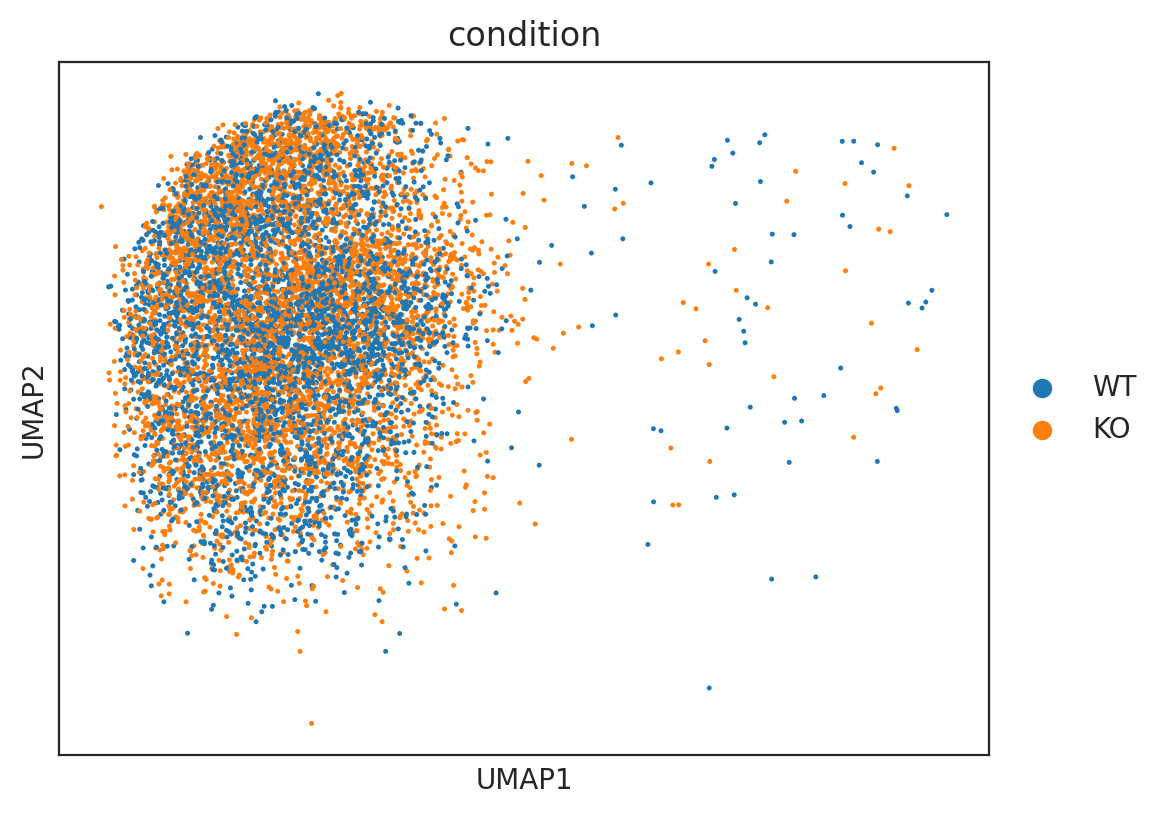

In [10]:
sc.pl.umap(stream_obj, color=['condition'], show=False)

<AxesSubplot: title={'center': 'condition'}, xlabel='X_dr1', ylabel='X_dr2'>

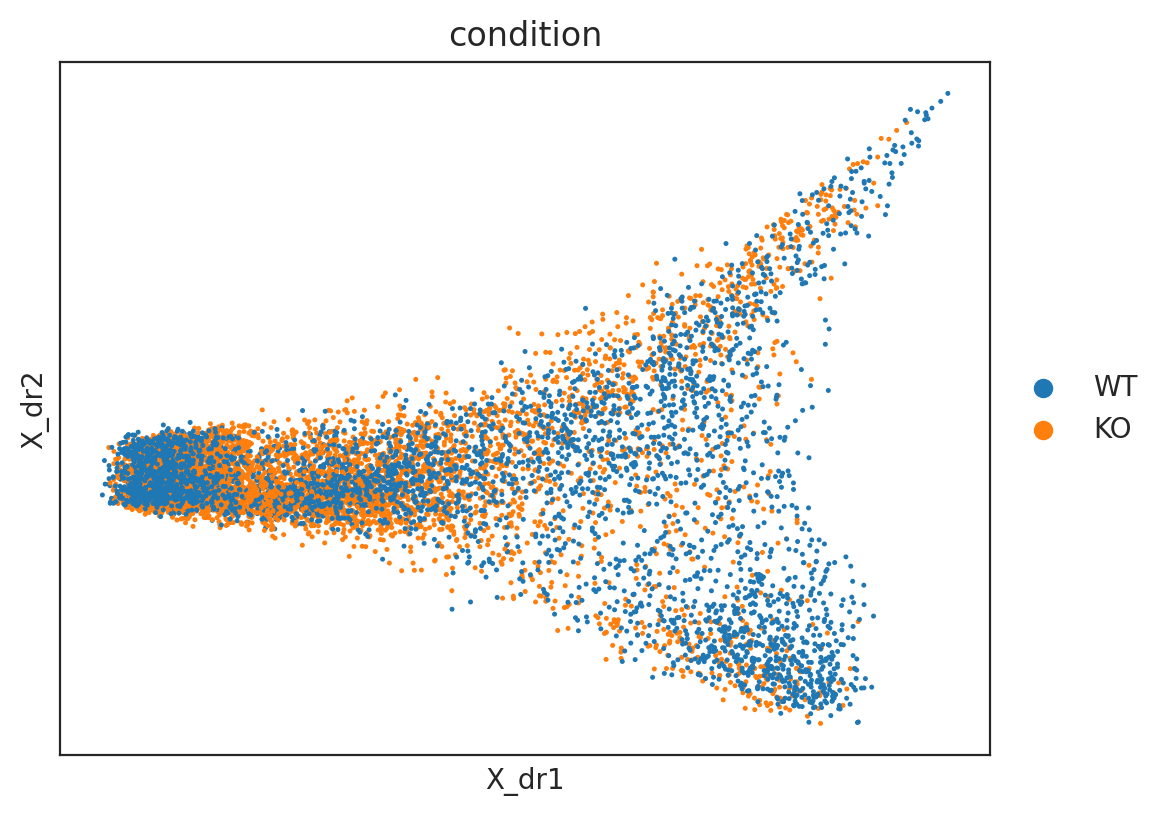

In [11]:
sc.pl.embedding(stream_obj, basis='X_dr', color=['condition'], show=False)

In [12]:
oracle.adata.obsm['X_dr'] = stream_obj.obsm['X_dr'].copy()

<AxesSubplot: title={'center': 'condition'}, xlabel='X_dr1', ylabel='X_dr2'>

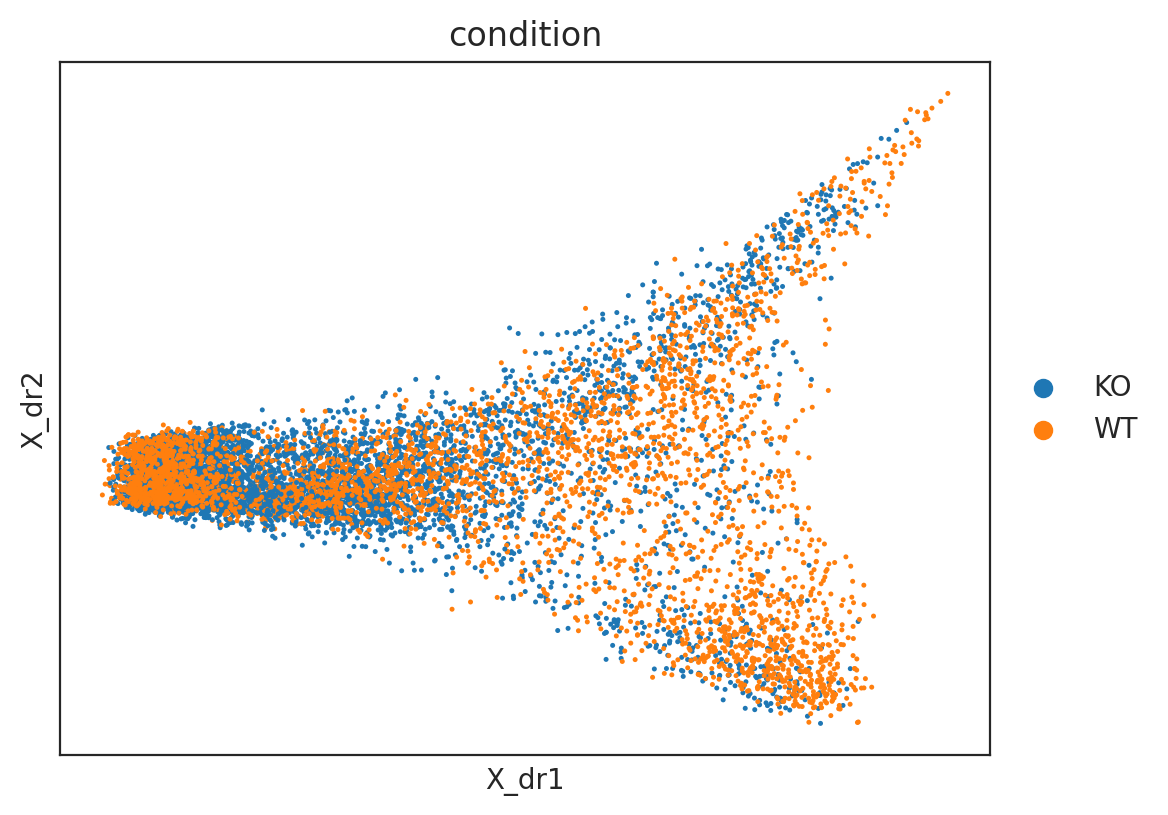

In [13]:
sc.pl.embedding(oracle.adata, basis='X_dr', color=['condition'], show=False)

In [ ]:
oracle.embedding = oracle.adata.obsm['X_dr']
oracle.adata.obsm['X_umap'] = oracle.adata.obsm['X_dr']

In [14]:
oracle

Oracle object

Meta data
    celloracle version used for instantiation: 0.20.0
    n_cells: 9280
    n_genes: 2000
    cluster_name: condition
    dimensional_reduction_name: X_umap
    n_target_genes_in_TFdict: 21256 genes
    n_regulatory_in_TFdict: 1093 genes
    n_regulatory_in_both_TFdict_and_scRNA-seq: 84 genes
    n_target_genes_both_TFdict_and_scRNA-seq: 1605 genes
    k_for_knn_imputation: 747
Status
    Gene expression matrix: Ready
    BaseGRN: Ready
    PCA calculation: Done
    Knn imputation: Done
    GRN calculation for simulation: Done

# Single TF perturbation simulation

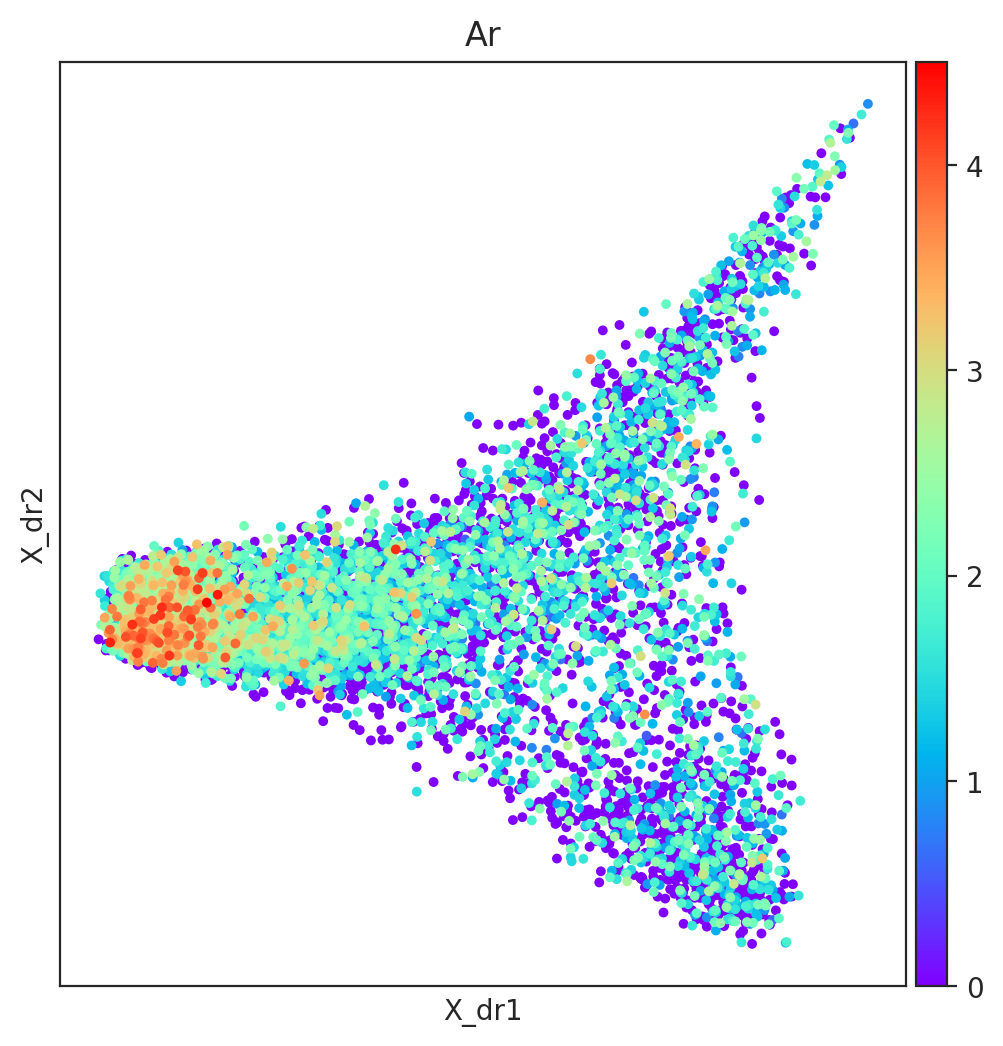

In [15]:
# Visualize pseudotime
fig, ax = plt.subplots(figsize=[6,6])
sc.pl.embedding(adata=oracle.adata, basis= 'X_dr', ax=ax, cmap="rainbow", color=["Ar"],s=50)

In [ ]:
goi = 'Ar'
print(f'Simulating perturbation for {goi}', flush=True)
oracle.simulate_shift(perturb_condition={goi: 0.0}, GRN_unit = "cluster", n_propagation=2) # If kernal crashes increase the memory limit of jupyter notebook
print(f'Estimating transition probability for {goi}', flush=True)
oracle.estimate_transition_prob(n_neighbors=750, knn_random=True, sampled_fraction=1) # Get transition probability
print(f'Calculating embedding for {goi}', flush=True)
oracle.calculate_embedding_shift(sigma_corr=0.05) # Calculate embedding

In [ ]:
n_grid=40
oracle.calculate_p_mass(smooth=0.8, n_grid=n_grid, n_neighbors=750)
# Search for best min_mass.
oracle.suggest_mass_thresholds(n_suggestion=12)

In [ ]:
min_mass=60
oracle.calculate_mass_filter(min_mass=min_mass, plot=True)

In [ ]:
scale_simulation=15

fig, ax = plt.subplots(1, 3,  figsize=[18, 6])
oracle.plot_cluster_whole(ax=ax[0], s=10)
ax[0].set_title(f"Simulated cell identity shift vector: {goi} KO")
oracle.plot_simulation_flow_on_grid(scale=scale_simulation, ax=ax[0], show_background=False)
oracle.plot_cluster_whole(ax=ax[1], s=10)
ax[1].set_title(f"Randomized simulation shift vector: {goi} KO")
oracle.plot_simulation_flow_random_on_grid(scale=scale_simulation, ax=ax[1], show_background=False)
ax[2].set_title(f"Clustered cell identity")  
sc.pl.umap(oracle.adata, color=['condition'], ax=ax[2], show=False)

In [ ]:
from numpy import shape
display(shape(oracle.flow))
display(len(oracle.flow_grid))